# Miracle Invoker
### Team Member
1. Puran Karki
2. Pravesh Bahakari
3. Nabin Yari
4. Manoj Bhattarai

The dataset selected for this project is the *E-Commerce Online Retail dataset*, which contains real transactions data from a UK-based online store. It has over 500,000 rows of records which make suitable for the Big Data analytic. 
This dataset is choosen because it is large, realistic and well structured which allow us to analyze customer behaviour, sales trands and product performance.

## Setup & Import
Install and import the necessary libraries for Spark and MongoDb

In [2]:
# Install necessary packages
%pip install pyspark pymongo dnspython

import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, count, when, desc, rank
from pyspark.sql.window import Window
import pymongo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


## Spark Session Initialization

In this step, we start Spark so we can work with our data.

We first import `SparkSession` and then create a Spark session using the builder.

- appName("BigDataProject") just gives a name to our project.
- master("local[*]" means Spark will run on our computer and use all available CPU cores.
- config("spark.driver.host", "127.0.0.1") helps Spark run properly on the local machine.

The `getOrCreate()` function creates a new Spark session if one does not exist, or uses the existing one.

This step is important because we need the Spark session before we can load and analyze any data.

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("BigDataProject") \
    .master("local[*]") \
    .config("spark.driver.host", "127.0.0.1") \
    .getOrCreate()

print("Spark started successfully")

Spark started successfully


## Loading dataset with header

In this step, we load the dataset into Spark using the `read.csv()` function. We use header=True so that the first row is treated as column names, and inferSchema=True so Spark can automatically detect the correct data types.

After loading the data, we use show(5) to display the first five rows. This helps us quickly check if the data has been loaded correctly.

We also use `printSchema()` to see the structure of the dataset, including column names and their data types. This is useful for understanding the data before cleaning and analysis.

In [4]:
online_df = spark.read.csv("data.csv", header=True, inferSchema=True)

online_df.show(5) #display top 5 row of data
online_df.printSchema() #display the table

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
only showing top 5 rows
root
 |-- InvoiceNo: string (nullable = true)
 |-

## Basic cleaning of Data
In this step, we clean the dataset to make sure the analysis is more accurate.

First, we use `dropna()` to remove any rows that contain missing values in any column. This helps us avoid problems caused by incomplete data.

Then, we filter the dataset to keep only rows where the Quantity is greater than 0. This removes invalid records such as returns or incorrect entries.

Finally, we use `show(5)` to display a few rows and check that the cleaned data looks correct.

In [5]:
new_online_df = online_df.dropna() #remove all the row which have null value in any column
df = new_online_df.filter(new_online_df["Quantity"] > 0) #remove quantity which are less or equal to 0
df.show(5)

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
only showing top 5 rows


## Simple analysis with spark SQL

### Sales analysis by country
In this step, we analyze how sales are distributed across different countries.

First, we create a temporary view called "sales" using `createOrReplaceTempView()`. This allows us to run SQL queries on the DataFrame.

Then, we use a Spark SQL query to group the data by country and calculate the total quantity sold in each country using `SUM(Quantity)`.

The results are sorted in descending order so that countries with the highest sales appear at the top.

We use `show()` to display the result in Spark, and then convert it to a Pandas DataFrame using `toPandas()` so that we can use it later for visualization.

In [8]:
df.createOrReplaceTempView("sales")

In [9]:
result = spark.sql("""
SELECT Country, SUM(Quantity) as Total_Quantity
FROM sales
GROUP BY Country
ORDER BY Total_Quantity DESC
""")

result.show()
pdf = result.toPandas()

+---------------+--------------+
|        Country|Total_Quantity|
+---------------+--------------+
| United Kingdom|       4269472|
|    Netherlands|        200937|
|           EIRE|        140525|
|        Germany|        119263|
|         France|        111472|
|      Australia|         84209|
|         Sweden|         36083|
|    Switzerland|         30083|
|          Spain|         27951|
|          Japan|         26016|
|        Belgium|         23237|
|         Norway|         19338|
|       Portugal|         16122|
|        Finland|         10704|
|Channel Islands|          9491|
|        Denmark|          8235|
|          Italy|          8112|
|         Cyprus|          6361|
|      Singapore|          5241|
|        Austria|          4881|
+---------------+--------------+
only showing top 20 rows


### Visualization of sales by country

Here, we visualize the countries with the highest sales.

First, we sort the data based on total quantity in descending order and select the top 10 countries. This helps us focus on the most important results.

Then, we create a bar chart using Matplotlib. The x-axis represents the countries, and the y-axis shows the total quantity sold.

We rotate the x-axis labels to make them easier to read and adjust the layout so everything fits properly.

Finally, we display the chart to clearly compare sales across different countries.

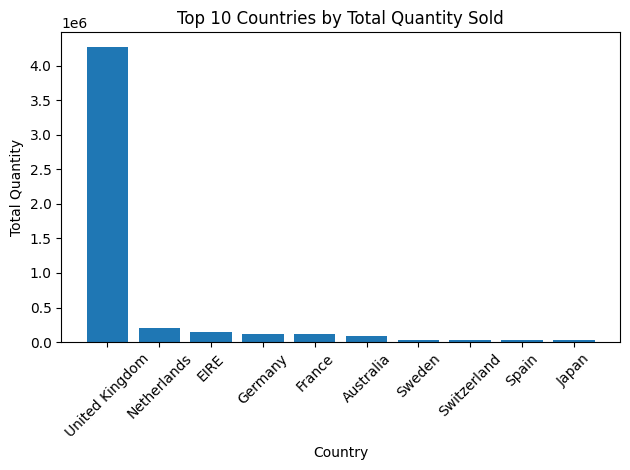

In [10]:
# Sort and take top 10 countries (cleaner graph)
pdf = pdf.sort_values(by="Total_Quantity", ascending=False).head(10)

plt.figure()
plt.bar(pdf["Country"], pdf["Total_Quantity"])
plt.title("Top 10 Countries by Total Quantity Sold")
plt.xlabel("Country")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Top Selling Products

Here, we find the products which are sold the most.

We use a Spark SQL query to group the data by product description and calculate the total quantity sold using `SUM(Quantity)`. The results are sorted in descending order so that the best-selling products appear first. We limit the output to the top 10 products.

We display the result using `show()` and convert it into a Pandas DataFrame using `toPandas()` for visualization.

In [11]:
result = spark.sql("""
SELECT Description, SUM(Quantity) as Total_Sold
FROM sales
GROUP BY Description
ORDER BY Total_Sold DESC
LIMIT 10
""")

result.show()
pdf = result.toPandas()

+--------------------+----------+
|         Description|Total_Sold|
+--------------------+----------+
|PAPER CRAFT , LIT...|     80995|
|MEDIUM CERAMIC TO...|     77916|
|WORLD WAR 2 GLIDE...|     54415|
|JUMBO BAG RED RET...|     46181|
|WHITE HANGING HEA...|     36725|
|ASSORTED COLOUR B...|     35362|
|PACK OF 72 RETROS...|     33693|
|      POPCORN HOLDER|     30931|
|  RABBIT NIGHT LIGHT|     27202|
|MINI PAINT SET VI...|     26076|
+--------------------+----------+



### Visualization of top selling products

Now, we create a bar chart to visualize the top selling products.

The product descriptions are shown on one axis, and the total quantity sold is shown on the other. We invert the axis so that the product with the highest sales appears at the top, making the chart easier to read.

This visualization helps us quickly identify which products are the most popular.

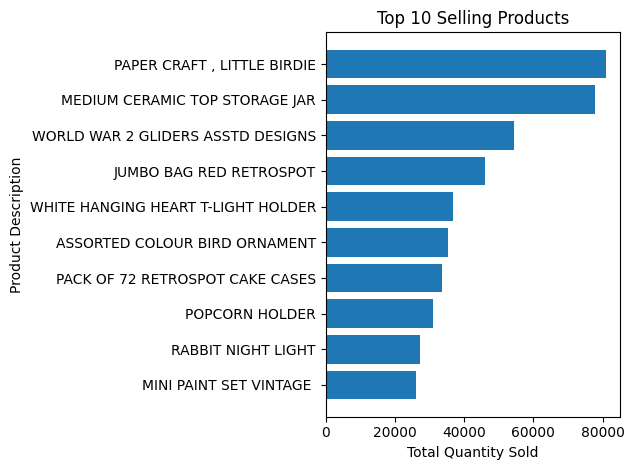

In [12]:
plt.figure()
plt.barh(pdf["Description"], pdf["Total_Sold"])
plt.title("Top 10 Selling Products")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Description")

plt.gca().invert_yaxis()  # highest on top
plt.tight_layout()

plt.show()

### Country generates the most money/ revenue

In this step, we calculate how much revenue each country generates.
We use a Spark SQL query to group the data by country and calculate revenue using `SUM(Quantity * UnitPrice)`. This gives us the total money generated from sales in each country.

The results are sorted in descending order so that the countries with the highest revenue appear at the top.

We display the results using `show()` and convert them into a Pandas DataFrame using `toPandas()` for visualization.


In [13]:
result = spark.sql("""
SELECT Country, SUM(Quantity * UnitPrice) as Revenue
FROM sales
GROUP BY Country
ORDER BY Revenue DESC
""")

result.show()
pdf = result.toPandas()

+---------------+------------------+
|        Country|           Revenue|
+---------------+------------------+
| United Kingdom| 7308391.554000117|
|    Netherlands|285446.33999999997|
|           EIRE| 265545.9000000003|
|        Germany| 228867.1399999999|
|         France|209024.05000000005|
|      Australia|138521.30999999997|
|          Spain| 61577.10999999999|
|    Switzerland| 56443.94999999997|
|        Belgium|          41196.34|
|         Sweden|          38378.33|
|          Japan|          37416.37|
|         Norway|36165.439999999995|
|       Portugal| 33439.89000000001|
|        Finland|          22546.08|
|      Singapore|          21279.29|
|Channel Islands|20450.440000000002|
|        Denmark|18955.339999999997|
|          Italy|17483.239999999998|
|         Cyprus|13590.380000000001|
|        Austria|          10198.68|
+---------------+------------------+
only showing top 20 rows


### Visualization of revenue generates by country
Next here, we create a bar chart to visualize the top countries by revenue. The chart shows countries on one axis and revenue on the other. We invert the axis so that the country with the highest revenue appears at the top, making the chart easier to read.This helps us quickly understand which countries contribute the most to overall revenue.

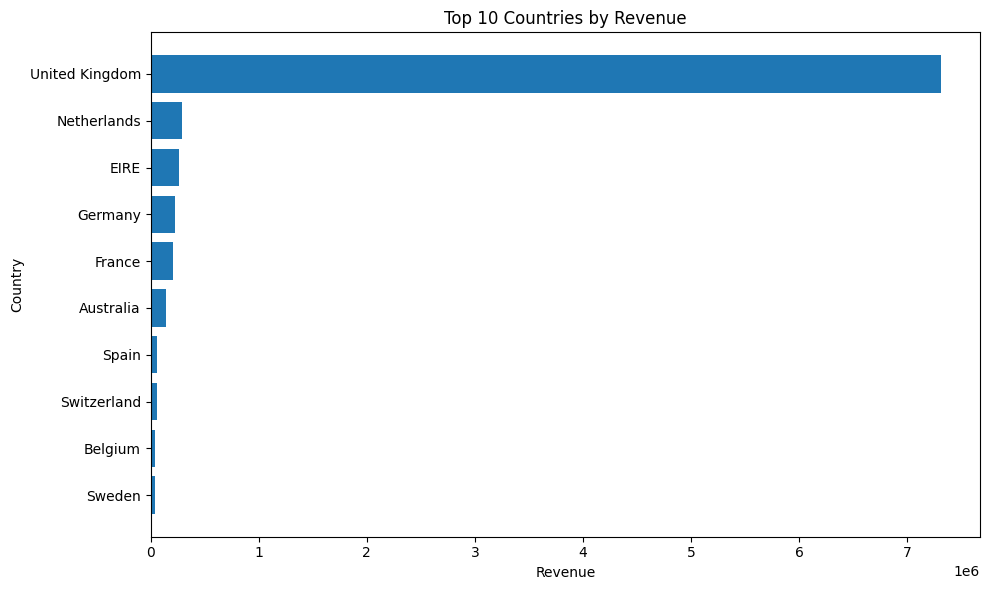

In [15]:
pdf = pdf.sort_values(by="Revenue", ascending=False).head(10)
plt.figure(figsize=(10,6))

plt.barh(pdf["Country"], pdf["Revenue"])

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

### Most active customers based in CustomerId

In this step, we identify the customers who place the most orders.
We use a Spark SQL query to group the data by `CustomerID` and count the number of orders using `COUNT(*)`. The results are sorted in descending order so that the most active customers appear at the top. We limit the output to the top 10 customers.

We display the results using `show()` and convert them into a Pandas DataFrame using `toPandas()` for visualization.

In [16]:
result = spark.sql("""
SELECT CustomerID, COUNT(*) as Orders
FROM sales
GROUP BY CustomerID
ORDER BY Orders DESC
LIMIT 10
""")

result.show()
pdf = result.toPandas()

+----------+------+
|CustomerID|Orders|
+----------+------+
|     17841|  7847|
|     14911|  5677|
|     14096|  5111|
|     12748|  4596|
|     14606|  2700|
|     15311|  2379|
|     14646|  2080|
|     13089|  1818|
|     13263|  1677|
|     14298|  1637|
+----------+------+



### Visualization of most active customers based on customerId

Here, we create a horizontal bar chart to visualize the top customers based on the number of orders.
Customer IDs are shown on one axis and the number of orders on the other. We convert the IDs to string for better display and invert the axis so that the most active customer appears at the top.
This chart makes it easy to see which customers contribute the most activity.

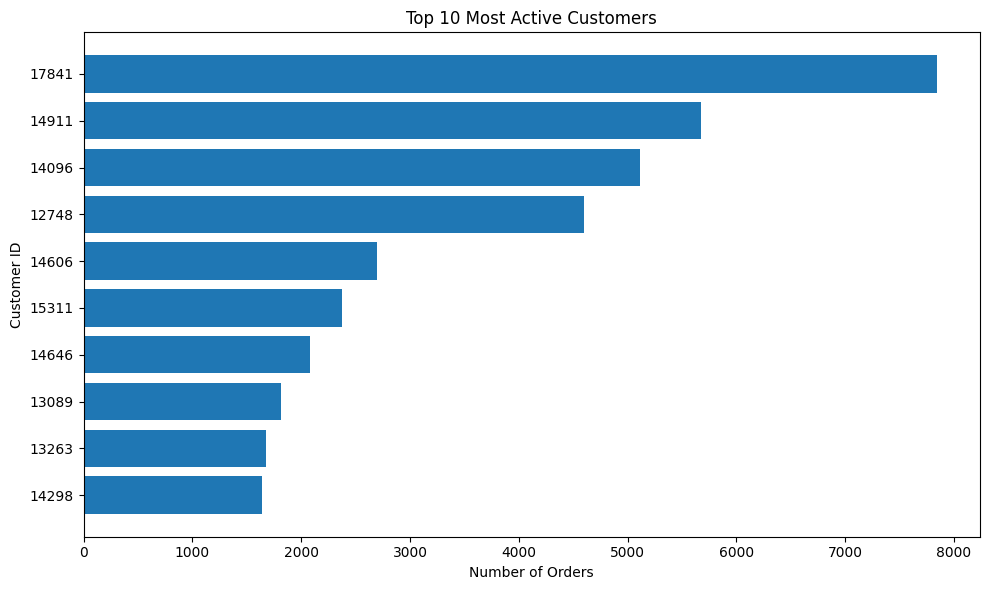

In [18]:
plt.figure(figsize=(10,6))
plt.barh(pdf["CustomerID"].astype(str), pdf["Orders"])
plt.title("Top 10 Most Active Customers")
plt.xlabel("Number of Orders")
plt.ylabel("Customer ID")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()